# 25. One-shot final TEST evaluation

N25 opens the untouched TEST period exactly once. N22 defines the causal state, N23 defines synthetic delta-hedged option mechanics, and N24 freezes the Gradient Boosting models and the economic decision. N25 makes no model, feature, threshold, or policy-selection decision.

$$
\Delta RMSE_{\mathrm{TEST}}
= RMSE_{S+H,\mathrm{TEST}}-RMSE_{S,\mathrm{TEST}}.
$$

The pre-TEST primary economic decision is fixed:

$$
\boxed{\text{FINAL POLICY = FLAT}.}
$$

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

PROJECT_DIR = Path.cwd().resolve()
PROCESSED = PROJECT_DIR / "Data" / "processed"
INTERIM = PROJECT_DIR / "Data" / "interim"
HOURLY = PROJECT_DIR / "Data" / "usdjpy_hourly_data"
FIGURES = PROJECT_DIR / "figures"

OPEN_FINAL_TEST = False
TARGET_TOL = 1e-12
BLOCK_LENGTH = 5
BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 24
MINIMUM_TRADES = 4

execution_warning_log = []
original_showwarning = warnings.showwarning

def record_notebook_warning(message, category, filename, lineno, file=None, line=None):
    execution_warning_log.append((str(message), category.__name__, filename, lineno))
    original_showwarning(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = record_notebook_warning

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def rmse(actual, predicted):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2)))

def mae(actual, predicted):
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(predicted))))

# 2. Pre-TEST freeze manifest

The following provenance gate is evaluated before any TEST target, option outcome, or policy PnL is constructed. Any failed check stops N25.

In [2]:
paths = {
    "n22": PROCESSED / "22_application_causal_state_panel.csv",
    "n23": PROCESSED / "23_application_option_pnl_panel.csv",
    "daily": PROCESSED / "usdjpy_daily_model_panel.csv",
    "model_spec": PROCESSED / "24_frozen_model_specification.csv",
    "policy_spec": PROCESSED / "24_frozen_policy_specification.csv",
    "validation_bootstrap": PROCESSED / "24_validation_incremental_bootstrap.csv",
    "validation_predictive": PROCESSED / "24_validation_predictive_comparison.csv",
    "validation_policy": PROCESSED / "24_validation_policy_comparison.csv",
    "mid": INTERIM / "usdjpy_hourly_mid_audited.csv",
    "bid": HOURLY / "usdjpy_hourly_bid.csv",
    "ask": HOURLY / "usdjpy_hourly_ask.csv",
}
assert all(path.is_file() for path in paths.values())

n22_notebook = PROJECT_DIR / "22_application_causal_state_and_forward_economic_target.ipynb"
n23_notebook = PROJECT_DIR / "23_application_option_contract_and_pnl_engine.ipynb"
n24_notebook = PROJECT_DIR / "24_application_nonparametric_signal_and_economic_validation.ipynb"
upstream_hashes = {"N22": sha256(n22_notebook), "N23": sha256(n23_notebook), "N24": sha256(n24_notebook)}

n22_state = pd.read_csv(paths["n22"], parse_dates=["model_day", "next_model_day"])
n23_panel = pd.read_csv(paths["n23"], parse_dates=["model_day", "next_model_day", "decision_boundary", "scheduled_expiry_boundary", "actual_entry_timestamp", "actual_expiry_timestamp"])
model_spec = pd.read_csv(paths["model_spec"])
policy_spec = pd.read_csv(paths["policy_spec"])
validation_bootstrap = pd.read_csv(paths["validation_bootstrap"])
validation_predictive = pd.read_csv(paths["validation_predictive"])
validation_policy = pd.read_csv(paths["validation_policy"])

feature_sets = {
    "S_ONLY": ["S_next"],
    "HIDDEN_ONLY": ["D", "Z_R", "Z_I_prev"],
    "COMBINED": ["S_next", "D", "Z_R", "Z_I_prev"],
}
expected_thresholds = [0.23468983650018221, 0.2682547839622752, 0.434647513702269]
frozen_thresholds = sorted(validation_policy.loc[validation_policy.policy.eq("ML_THRESHOLD"), "threshold"].dropna().astype(float).unique().tolist())
artifact_paths = {
    family: PROJECT_DIR / path
    for family, path in zip(model_spec.feature_family, model_spec.model_artifact_path)
}
observed_model_hashes = {family: sha256(path) for family, path in artifact_paths.items()}
expected_model_hashes = dict(zip(model_spec.feature_family, model_spec.sha256))

manifest = []
def check(component, expected, observed, passed):
    manifest.append({"component": component, "expected_frozen_value": str(expected), "observed_value": str(observed), "verification_result": bool(passed)})

for name, digest in upstream_hashes.items():
    check(f"{name} notebook SHA256", "recorded", digest, len(digest) == 64)
check("model family", "GradientBoostingRegressor", model_spec.model_family.tolist(), model_spec.model_family.eq("GradientBoostingRegressor").all())
check("target", "C_next", model_spec.target.tolist(), model_spec.target.eq("C_next").all())
for family, features in feature_sets.items():
    observed = json.loads(model_spec.loc[model_spec.feature_family.eq(family), "feature_names"].iloc[0])
    check(f"{family} features", features, observed, observed == features)
for column, expected in {"max_depth": 1, "min_samples_leaf": 20, "n_estimators": 100, "learning_rate": .05, "loss": "squared_error", "random_state": 24}.items():
    check(f"GB {column}", expected, model_spec[column].tolist(), model_spec[column].eq(expected).all())
for family in feature_sets:
    check(f"{family} artifact SHA256", expected_model_hashes[family], observed_model_hashes[family], observed_model_hashes[family] == expected_model_hashes[family])
check("final policy", "FLAT", policy_spec.final_policy.iloc[0], policy_spec.final_policy.eq("FLAT").all())
check("policy frozen", True, policy_spec.policy_frozen.iloc[0], policy_spec.policy_frozen.eq(True).all())
check("N24 TEST used in selection", False, policy_spec.test_used_in_selection.iloc[0], policy_spec.test_used_in_selection.eq(False).all())
check("frozen ML_THRESHOLD values", expected_thresholds, frozen_thresholds, np.allclose(expected_thresholds, frozen_thresholds))
check("risk-weighted objective", "mean return / sample standard deviation; not annualised", policy_spec.risk_weighted_objective.iloc[0], policy_spec.risk_weighted_objective.eq("mean return / sample standard deviation; not annualised").all())
check("benchmark definitions", "TYPE_ONLY benchmark retained", policy_spec.benchmark_only_policies.iloc[0], "TYPE_ONLY" in policy_spec.benchmark_only_policies.iloc[0])

freeze_manifest = pd.DataFrame(manifest)
display(freeze_manifest)
assert freeze_manifest.verification_result.all()
freeze_manifest_passed = True

,component,expected_frozen_value,observed_value,verification_result
0,N22 notebook SHA256,recorded,d985a9e2ada92b6be6970b8d5299e14a07b5ea6dbc5469...,True
1,N23 notebook SHA256,recorded,1aa82b5467ad31138a1e449f6385520f1d289e913aedbe...,True
2,N24 notebook SHA256,recorded,c14ea850b3daf9f852902aae105c36130ee22b69963fe6...,True
3,model family,GradientBoostingRegressor,"['GradientBoostingRegressor', 'GradientBoostin...",True
4,target,C_next,"['C_next', 'C_next', 'C_next']",True
5,S_ONLY features,['S_next'],['S_next'],True
6,HIDDEN_ONLY features,"['D', 'Z_R', 'Z_I_prev']","['D', 'Z_R', 'Z_I_prev']",True
7,COMBINED features,"['S_next', 'D', 'Z_R', 'Z_I_prev']","['S_next', 'D', 'Z_R', 'Z_I_prev']",True
8,GB max_depth,1,"[1, 1, 1]",True
9,GB min_samples_leaf,20,"[20, 20, 20]",True


# 3. Formal TEST opening boundary

All model, feature, policy, threshold and economic-design choices were frozen in N24 before this point. The following cells perform the one-shot final TEST evaluation. No design change is permitted after TEST is opened.

In [3]:
assert freeze_manifest_passed
OPEN_FINAL_TEST = True
assert OPEN_FINAL_TEST is True
print("N25 formal TEST opening: ACTIVE")

N25 formal TEST opening: ACTIVE


# 4. Forward-target reconstruction audit

N22 deliberately leaves TEST targets missing. N25 reconstructs them only after the opening boundary using the exact canonical join:

$$
G_{t+1}=\log\left(\frac{R_{t+1}}{I_t}\right),
\qquad C_{t+1}=G_{t+1}+S_{t+1}.
$$

In [4]:
assert OPEN_FINAL_TEST is True
next_realised = n22_state[["model_day", "R_t"]].rename(columns={"model_day": "next_model_day", "R_t": "R_next"})
evaluation_panel = n22_state.merge(next_realised, on="next_model_day", how="left", validate="many_to_one")
evaluation_panel["G_next_reconstructed"] = np.where(
    evaluation_panel.R_next.gt(0) & evaluation_panel.I_t.gt(0),
    np.log(evaluation_panel.R_next / evaluation_panel.I_t),
    np.nan,
)
evaluation_panel["C_next_reconstructed"] = evaluation_panel.G_next_reconstructed + evaluation_panel.S_next

target_audit = []
for stage in ["DEVELOPMENT", "VALIDATION"]:
    frame = evaluation_panel.loc[evaluation_panel.application_stage.eq(stage)]
    target_audit.append({
        "stage": stage,
        "n_compared": int(frame.G_next.notna().sum()),
        "max_abs_G_next_error": float(np.abs(frame.G_next - frame.G_next_reconstructed).max()),
        "max_abs_C_next_error": float(np.abs(frame.C_next - frame.C_next_reconstructed).max()),
    })
target_reconstruction_audit = pd.DataFrame(target_audit)
display(target_reconstruction_audit)
assert target_reconstruction_audit[["max_abs_G_next_error", "max_abs_C_next_error"]].le(TARGET_TOL).all().all()

test_mask = evaluation_panel.application_stage.eq("TEST")
assert n22_state.loc[test_mask, ["G_next", "C_next"]].isna().all().all()
assert evaluation_panel.loc[test_mask & evaluation_panel.next_model_day.isna(), ["G_next_reconstructed", "C_next_reconstructed"]].isna().all().all()

,stage,n_compared,max_abs_G_next_error,max_abs_C_next_error
0,DEVELOPMENT,1171,4.440892e-16,4.440892e-16
1,VALIDATION,1194,4.440892e-16,4.440892e-16


# 5. Final TEST predictive evaluation

The identical frozen N24 primary eligibility logic is applied after target reconstruction. The models are loaded from N24 and only `.predict()` is permitted.

In [5]:
test_state = evaluation_panel.loc[test_mask].copy()
finite_columns = ["S_next", "D", "Z_R", "Z_I_prev", "C_next_reconstructed"]
test_state["state_is_complete"] = test_state[finite_columns].apply(np.isfinite).all(axis=1)
primary_mask = (
    test_state.state_scored.eq(True)
    & test_state.feature_complete.eq(True)
    & ~test_state.is_known_primary_event_pair.eq(True)
    & test_state.state_is_complete
)
primary_test = test_state.loc[primary_mask].sort_values("model_day").copy()
test_coverage = pd.DataFrame([{
    "total_TEST_rows": len(test_state),
    "reconstructed_target_available": int(test_state.C_next_reconstructed.notna().sum()),
    "complete_S_features": int(test_state[["S_next"]].apply(np.isfinite).all(axis=1).sum()),
    "complete_H_features": int(test_state[["D", "Z_R", "Z_I_prev"]].apply(np.isfinite).all(axis=1).sum()),
    "complete_combined_features": int(test_state[["S_next", "D", "Z_R", "Z_I_prev"]].apply(np.isfinite).all(axis=1).sum()),
    "current_known_event_exclusions": int(test_state.is_known_primary_event_pair.eq(True).sum()),
    "final_common_TEST_sample": len(primary_test),
}])
display(test_coverage)
assert len(primary_test) > 0

frozen_models = {family: joblib.load(artifact_paths[family]) for family in feature_sets}
test_forecasts = primary_test[["model_day", "next_model_day", "C_next_reconstructed", "G_next_reconstructed", "S_next", "D", "Z_R", "Z_I_prev", "hidden_type"]].rename(columns={"C_next_reconstructed": "C_next", "G_next_reconstructed": "G_next"}).copy()
test_forecasts["C_hat_ORDINARY"] = 0.0
for family, features in feature_sets.items():
    test_forecasts[f"C_hat_{family}"] = frozen_models[family].predict(primary_test[features])
test_forecasts["G_hat_ORDINARY"] = -test_forecasts.S_next
test_forecasts["G_hat_S_ONLY"] = -test_forecasts.S_next + test_forecasts.C_hat_S_ONLY
test_forecasts["G_hat_COMBINED"] = -test_forecasts.S_next + test_forecasts.C_hat_COMBINED

predictive_rows = []
for name, column in [("ORDINARY", "C_hat_ORDINARY"), ("S_ONLY", "C_hat_S_ONLY"), ("HIDDEN_ONLY", "C_hat_HIDDEN_ONLY"), ("COMBINED", "C_hat_COMBINED")]:
    predicted = test_forecasts[column]
    predictive_rows.append({"model": name, "n": len(test_forecasts), "RMSE": rmse(test_forecasts.C_next, predicted), "MAE": mae(test_forecasts.C_next, predicted), "correlation": np.nan if name == "ORDINARY" else float(np.corrcoef(test_forecasts.C_next, predicted)[0, 1])})
test_predictive_comparison = pd.DataFrame(predictive_rows)
ordinary_rmse = test_predictive_comparison.loc[test_predictive_comparison.model.eq("ORDINARY"), "RMSE"].iloc[0]
s_rmse = test_predictive_comparison.loc[test_predictive_comparison.model.eq("S_ONLY"), "RMSE"].iloc[0]
test_predictive_comparison["RMSE_difference_vs_ordinary"] = test_predictive_comparison.RMSE - ordinary_rmse
test_predictive_comparison["RMSE_difference_vs_S_only"] = test_predictive_comparison.RMSE - s_rmse
observed_test_delta = float(test_predictive_comparison.loc[test_predictive_comparison.model.eq("COMBINED"), "RMSE"].iloc[0] - s_rmse)
relative_test_improvement = float(-observed_test_delta / s_rmse)
display(test_predictive_comparison.round(6))
print("Ordinary correlation is undefined because the ordinary correction prediction is constant at zero.")

,total_TEST_rows,reconstructed_target_available,complete_S_features,complete_H_features,complete_combined_features,current_known_event_exclusions,final_common_TEST_sample
0,1209,1181,1181,1132,1122,487,659


,model,n,RMSE,MAE,correlation,RMSE_difference_vs_ordinary,RMSE_difference_vs_S_only
0,ORDINARY,659,0.797384,0.595482,NaN,0.000000,0.027989
1,S_ONLY,659,0.769396,0.575169,0.118215,-0.027989,0.000000
2,HIDDEN_ONLY,659,0.773376,0.575778,0.065778,-0.024008,0.003980
3,COMBINED,659,0.769411,0.574207,0.116097,-0.027974,0.000015


Ordinary correlation is undefined because the ordinary correction prediction is constant at zero.


# 6. TEST incremental-information bootstrap

This repeats the frozen N24 paired moving-block bootstrap on generated TEST errors only. It performs no refitting.

,observed_delta_rmse,bootstrap_mean,p2_5,p97_5,fraction_combined_improves,block_length,reps,seed
0,0.000015,0.000459,-0.004701,0.005563,0.4334,5,5000,24


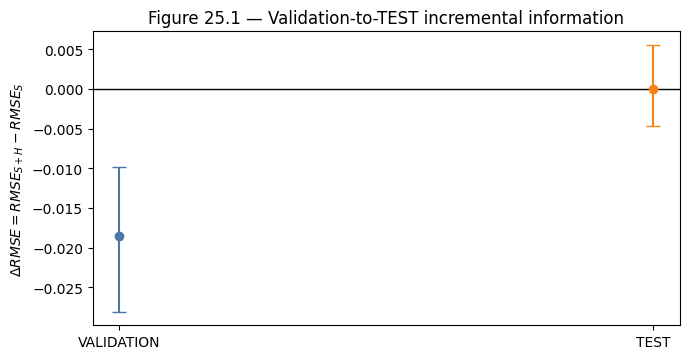

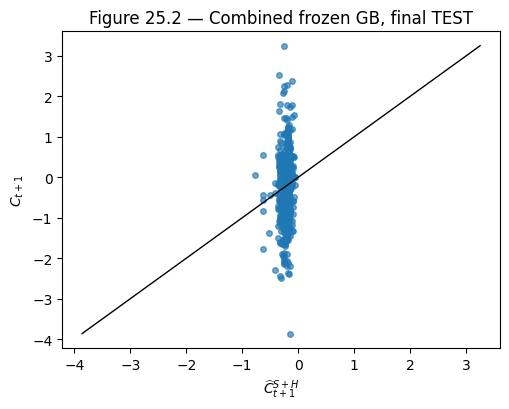

In [6]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
s_errors = (test_forecasts.C_next - test_forecasts.C_hat_S_ONLY).to_numpy()
combined_errors = (test_forecasts.C_next - test_forecasts.C_hat_COMBINED).to_numpy()
starts = np.arange(len(s_errors) - BLOCK_LENGTH + 1)
test_bootstrap_deltas = np.empty(BOOTSTRAP_REPS)
for replication in range(BOOTSTRAP_REPS):
    indices = []
    while len(indices) < len(s_errors):
        start = int(rng.choice(starts))
        indices.extend(range(start, start + BLOCK_LENGTH))
    indices = np.asarray(indices[:len(s_errors)])
    test_bootstrap_deltas[replication] = np.sqrt(np.mean(combined_errors[indices] ** 2)) - np.sqrt(np.mean(s_errors[indices] ** 2))
test_bootstrap_summary = pd.DataFrame([{
    "observed_delta_rmse": observed_test_delta,
    "bootstrap_mean": float(test_bootstrap_deltas.mean()),
    "p2_5": float(np.quantile(test_bootstrap_deltas, .025)),
    "p97_5": float(np.quantile(test_bootstrap_deltas, .975)),
    "fraction_combined_improves": float(np.mean(test_bootstrap_deltas < 0)),
    "block_length": BLOCK_LENGTH, "reps": BOOTSTRAP_REPS, "seed": BOOTSTRAP_SEED,
}])
display(test_bootstrap_summary.round(6))

validation_delta = float(validation_predictive.loc[validation_predictive.model.eq("COMBINED"), "rmse_change_vs_s_only"].iloc[0])
validation_interval = np.quantile(validation_bootstrap.delta_rmse, [.025, .975])
test_interval = test_bootstrap_summary.loc[0, ["p2_5", "p97_5"]].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(7, 3.7))
for label, estimate, interval, color in [("VALIDATION", validation_delta, validation_interval, "#4c78a8"), ("TEST", observed_test_delta, test_interval, "#f58518")]:
    ax.errorbar(label, estimate, yerr=[[estimate - interval[0]], [interval[1] - estimate]], fmt="o", capsize=5, color=color)
ax.axhline(0, color="black", linewidth=1)
ax.set(ylabel="$\\Delta RMSE = RMSE_{S+H}-RMSE_S$", title="Figure 25.1 — Validation-to-TEST incremental information")
fig.tight_layout(); fig.savefig(FIGURES / "25_figure_validation_to_test_delta_rmse.png", dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(test_forecasts.C_hat_COMBINED, test_forecasts.C_next, s=16, alpha=.65)
limits = [min(test_forecasts.C_hat_COMBINED.min(), test_forecasts.C_next.min()), max(test_forecasts.C_hat_COMBINED.max(), test_forecasts.C_next.max())]
ax.plot(limits, limits, color="black", linewidth=1)
ax.set(xlabel="$\\widehat C_{t+1}^{S+H}$", ylabel="$C_{t+1}$", title="Figure 25.2 — Combined frozen GB, final TEST")
fig.tight_layout(); fig.savefig(FIGURES / "25_figure_test_predicted_vs_realised.png", dpi=180); plt.show()

# 7. N23 option-engine equivalence audit

The next two cells reproduce the frozen N23 implementation verbatim, except that `UNLOCK_TEST_PNL=True` is local to N25 and occurs only after the formal TEST opening. The engine is first compared with N23’s authoritative mechanically complete DEVELOPMENT/VALIDATION contracts.

In [7]:
NY_ZONE = 'America/New_York'
DECISION_HOUR = 17
MAX_ENTRY_DELAY_HOURS = 2
MAX_EXPIRY_LEAD_HOURS = 2
MIN_HEDGE_OBSERVATIONS = 12
MAX_INTERIOR_QUOTE_GAP_HOURS = 4
R_DOMESTIC = 0.0
R_FOREIGN = 0.0
TOL = 1e-10
n22 = n22_state.copy()
daily = pd.read_csv(PROCESSED / 'usdjpy_daily_model_panel.csv', parse_dates=['model_day'])
required_daily = {'model_day', 'implied_vol_decimal', 'iv_ann_var', 'iv_model_var'}
assert required_daily.issubset(daily.columns)
raw_iv = daily[['model_day', 'implied_vol_decimal', 'iv_ann_var', 'iv_model_var']].rename(columns={'implied_vol_decimal': 'iv_entry', 'iv_ann_var': 'iv_raw_variance', 'iv_model_var': 'I_t_model_daily'})
assert raw_iv.model_day.is_unique
assert np.allclose(raw_iv['iv_entry'].dropna(), np.sqrt(raw_iv.loc[raw_iv['iv_entry'].notna(), 'iv_raw_variance']), rtol=0, atol=1e-14)
n22 = n22.rename(columns={'I_t': 'I_t_model'}).merge(raw_iv, on='model_day', how='left', validate='one_to_one')
assert n22.loc[n22['application_stage'].isin(['DEVELOPMENT', 'VALIDATION']), 'iv_entry'].notna().all()
assert np.allclose(n22['I_t_model'], n22['I_t_model_daily'], rtol=0, atol=1e-14, equal_nan=True)
iv_verification = pd.DataFrame([{'max_abs_iv_entry_minus_sqrt_raw_variance': float(np.abs(n22['iv_entry'] - np.sqrt(n22['iv_raw_variance'])).max()), 'option_pricing_iv': 'RAW_BLOOMBERG_ATM_IV', 'causal_model_iv': 'WEEKDAY_NORMALISED_IV_STATE'}])
display(iv_verification)
mid = pd.read_csv(paths['mid'])
mid['source_time'] = pd.to_datetime(mid['timestamp_parsed'], utc=True)
mid['mid'] = pd.to_numeric(mid['mid_close'], errors='coerce')
bid = pd.read_csv(paths['bid'], usecols=['timestamp', 'close']).rename(columns={'close': 'bid'})
ask = pd.read_csv(paths['ask'], usecols=['timestamp', 'close']).rename(columns={'close': 'ask'})
for frame in [bid, ask]:
    frame['source_time'] = pd.to_datetime(frame.pop('timestamp'), utc=True)
quotes = mid[['source_time', 'mid']].merge(bid, on='source_time', how='left', validate='one_to_one').merge(ask, on='source_time', how='left', validate='one_to_one')
quotes['bid'] = pd.to_numeric(quotes['bid'], errors='coerce')
quotes['ask'] = pd.to_numeric(quotes['ask'], errors='coerce')
quotes['timestamp'] = quotes['source_time'] + pd.Timedelta(hours=1)
quotes['valid'] = quotes[['mid', 'bid', 'ask']].notna().all(axis=1) & quotes['mid'].gt(0) & quotes['bid'].gt(0) & quotes['ask'].ge(quotes['bid'])
quotes = quotes.sort_values('timestamp').reset_index(drop=True)
mid_error = np.abs(quotes.loc[quotes.valid, 'mid'] - (quotes.loc[quotes.valid, 'bid'] + quotes.loc[quotes.valid, 'ask']) / 2).max()
assert mid_error < 1e-10 and quotes.timestamp.is_unique
test_start = n22.loc[n22.application_stage.eq('TEST'), 'model_day'].min()
test_boundary = pd.Timestamp(test_start).tz_localize(NY_ZONE).replace(hour=DECISION_HOUR).tz_convert('UTC')
pretest_quotes = quotes.loc[quotes.timestamp.lt(test_boundary)].copy()
display(pd.DataFrame([{'hourly_rows': len(quotes), 'pretest_rows': len(pretest_quotes), 'maximum_midpoint_error': mid_error, 'interpolation_used': False}]))

def boundary(day):
    return pd.Timestamp(day).tz_localize(NY_ZONE).replace(hour=DECISION_HOUR).tz_convert('UTC')

def price(spot, strike, tau, sigma, rd=R_DOMESTIC, rf=R_FOREIGN):
    if min(spot, strike, tau, sigma) <= 0:
        raise ValueError('positive pricing inputs required')
    root_tau = math.sqrt(tau)
    d1 = (math.log(spot / strike) + (rd - rf + 0.5 * sigma ** 2) * tau) / (sigma * root_tau)
    d2 = d1 - sigma * root_tau
    foreign_discount = math.exp(-rf * tau)
    domestic_discount = math.exp(-rd * tau)
    call = spot * foreign_discount * norm.cdf(d1) - strike * domestic_discount * norm.cdf(d2)
    put = strike * domestic_discount * norm.cdf(-d2) - spot * foreign_discount * norm.cdf(-d1)
    return (call, put, d1)

def delta(spot, strike, tau, sigma, rd=R_DOMESTIC, rf=R_FOREIGN):
    """Return the Garman--Kohlhagen spot delta of one long straddle."""
    _, _, d1 = price(spot, strike, tau, sigma, rd, rf)
    foreign_discount_factor = math.exp(-rf * tau)
    return foreign_discount_factor * (2 * norm.cdf(d1) - 1)

def select_entry(b, q):
    x = q.loc[q.valid & q.timestamp.ge(b) & q.timestamp.le(b + pd.Timedelta(hours=MAX_ENTRY_DELAY_HOURS))]
    return None if x.empty else x.iloc[0]

def select_expiry(b, q):
    x = q.loc[q.valid & q.timestamp.le(b) & q.timestamp.ge(b - pd.Timedelta(hours=MAX_EXPIRY_LEAD_HOURS))]
    return None if x.empty else x.iloc[-1]

def hedge(path, strike, sigma, sign):
    entry, expiry = (path.iloc[0], path.iloc[-1])
    tau = (expiry.timestamp - entry.timestamp).total_seconds() / (365 * 24 * 3600)
    call, put, _ = price(entry.mid, strike, tau, sigma)
    holding = 0.0
    rows = []
    for i, row in path.iloc[:-1].iterrows():
        rem = (expiry.timestamp - row.timestamp).total_seconds() / (365 * 24 * 3600)
        target = -sign * delta(row.mid, strike, rem, sigma, R_DOMESTIC, R_FOREIGN)
        trade = target - holding
        px = row.ask if trade > 0 else row.bid if trade < 0 else row.mid
        rows.append((row.timestamp, 'entry_hedge' if i == 0 else 'interior_rebalance', row.bid, row.ask, row.mid, rem, sigma, delta(row.mid, strike, rem, sigma, R_DOMESTIC, R_FOREIGN), target, holding, trade, px, -trade * px, -trade * row.mid))
        holding = target
    trade = -holding
    px = expiry.ask if trade > 0 else expiry.bid if trade < 0 else expiry.mid
    rows.append((expiry.timestamp, 'terminal_unwind', expiry.bid, expiry.ask, expiry.mid, 0.0, sigma, np.nan, 0.0, holding, trade, px, -trade * px, -trade * expiry.mid))
    ledger = pd.DataFrame(rows, columns=['timestamp', 'transaction_type', 'spot_bid', 'spot_ask', 'spot_mid', 'remaining_maturity_years', 'contract_iv', 'straddle_delta', 'target_usd_hedge', 'previous_usd_hedge', 'usd_hedge_trade', 'execution_price', 'jpy_cashflow_bidask', 'jpy_cashflow_mid'])
    payoff = abs(expiry.mid - strike)
    hmid = ledger.jpy_cashflow_mid.sum()
    hba = ledger.jpy_cashflow_bidask.sum()
    pmid = -sign * (call + put) + sign * payoff + hmid
    pba = -sign * (call + put) + sign * payoff + hba
    return ({'call_premium': call, 'put_premium': put, 'straddle_premium': call + put, 'maturity_years': tau, 'terminal_spot': expiry.mid, 'option_payoff': payoff, 'pnl_mid': pmid, 'pnl_bidask': pba, 'hedge_pnl_mid': hmid, 'hedge_pnl_bidask': hba, 'spot_transaction_cost': pmid - pba, 'turnover': ledger.usd_hedge_trade.abs().sum()}, ledger)

,max_abs_iv_entry_minus_sqrt_raw_variance,option_pricing_iv,causal_model_iv
0,2.373102e-15,RAW_BLOOMBERG_ATM_IV,WEEKDAY_NORMALISED_IV_STATE


,hourly_rows,pretest_rows,maximum_midpoint_error,interpolation_used
0,149842,120988,2.842171e-14,False


In [8]:
UNLOCK_TEST_PNL = True
def blank(row):
    d = {'model_day': row.model_day, 'next_model_day': row.next_model_day, 'application_stage': row.application_stage, 'canonical_index': row.canonical_index, 'I_t_model': row.I_t_model, 'iv_raw_variance': row.iv_raw_variance, 'iv_entry': row.iv_entry, 'decision_boundary': boundary(row.model_day), 'scheduled_expiry_boundary': boundary(row.next_model_day), 'actual_entry_timestamp': pd.NaT, 'actual_expiry_timestamp': pd.NaT, 'entry_delay_hours': np.nan, 'expiry_lead_hours': np.nan, 'maturity_years': np.nan, 'spot_entry_bid': np.nan, 'spot_entry_ask': np.nan, 'spot_entry_mid': np.nan, 'strike': np.nan, 'call_premium': np.nan, 'put_premium': np.nan, 'straddle_premium': np.nan, 'terminal_spot': np.nan, 'option_payoff': np.nan, 'n_hedge_observations': np.nan, 'max_quote_gap_hours': np.nan, 'entry_available': False, 'expiry_available': False, 'hedge_path_available': False, 'contract_complete': False, 'exclusion_reason': '', 'pnl_unlocked': False, 'option_pricing_type': 'SYNTHETIC_GARMAN_KOHLHAGEN', 'rates_assumption': 'ZERO_DOMESTIC_AND_FOREIGN', 'strike_convention': 'SPOT_ATM', 'hedge_volatility_convention': 'ENTRY_RAW_ATM_IV_FIXED', 'option_pricing_iv': 'RAW_BLOOMBERG_ATM_IV', 'causal_model_iv': 'WEEKDAY_NORMALISED_IV_STATE'}
    for side in ['long', 'short']:
        for metric in ['pnl_mid', 'pnl_bidask', 'pnl_norm_mid', 'pnl_norm_bidask', 'spot_transaction_cost', 'hedge_turnover', 'hedge_pnl_mid', 'hedge_pnl_bidask']:
            d[f'{side}_{metric}'] = np.nan
    return d

def build(row):
    d = blank(row)
    if row.application_stage == 'TEST' and (not UNLOCK_TEST_PNL):
        d['exclusion_reason'] = 'TEST_PNL_LOCKED'
        return (d, [])
    if not UNLOCK_TEST_PNL and row.next_model_day >= test_start:
        d['exclusion_reason'] = 'TEST_PNL_LOCKED'
        return (d, [])
    if not np.isfinite(row.iv_entry) or row.iv_entry <= 0:
        d['exclusion_reason'] = 'MISSING_IV'
        return (d, [])
    q = quotes if UNLOCK_TEST_PNL else pretest_quotes
    e = select_entry(d['decision_boundary'], q)
    if e is None:
        d['exclusion_reason'] = 'NO_ENTRY_QUOTE'
        return (d, [])
    d.update(entry_available=True, actual_entry_timestamp=e.timestamp, entry_delay_hours=(e.timestamp - d['decision_boundary']).total_seconds() / 3600)
    x = select_expiry(d['scheduled_expiry_boundary'], q)
    if x is None:
        d['exclusion_reason'] = 'NO_EXPIRY_QUOTE'
        return (d, [])
    d.update(expiry_available=True, actual_expiry_timestamp=x.timestamp, expiry_lead_hours=(d['scheduled_expiry_boundary'] - x.timestamp).total_seconds() / 3600)
    path = q.loc[q.valid & q.timestamp.between(e.timestamp, x.timestamp), ['timestamp', 'mid', 'bid', 'ask']].reset_index(drop=True)
    gaps = path.timestamp.diff().dt.total_seconds().div(3600)
    d['n_hedge_observations'] = len(path)
    d['max_quote_gap_hours'] = gaps.iloc[1:].max()
    if len(path) < MIN_HEDGE_OBSERVATIONS:
        d['exclusion_reason'] = 'INSUFFICIENT_HEDGE_OBSERVATIONS'
        return (d, [])
    if d['max_quote_gap_hours'] > MAX_INTERIOR_QUOTE_GAP_HOURS:
        d['exclusion_reason'] = 'INTERIOR_QUOTE_GAP_TOO_LARGE'
        return (d, [])
    sigma = row.iv_entry
    K = e.mid
    long, lled = hedge(path, K, sigma, 1.0)
    short, sled = hedge(path, K, sigma, -1.0)
    if long['straddle_premium'] <= 0:
        d['exclusion_reason'] = 'INVALID_PREMIUM'
        return (d, [])
    d.update(hedge_path_available=True, contract_complete=True, pnl_unlocked=True, actual_expiry_timestamp=x.timestamp, maturity_years=long['maturity_years'], spot_entry_bid=e.bid, spot_entry_ask=e.ask, spot_entry_mid=e.mid, strike=K, iv_entry=sigma, call_premium=long['call_premium'], put_premium=long['put_premium'], straddle_premium=long['straddle_premium'], terminal_spot=long['terminal_spot'], option_payoff=long['option_payoff'])
    for side, res in [('long', long), ('short', short)]:
        d[f'{side}_pnl_mid'] = res['pnl_mid']
        d[f'{side}_pnl_bidask'] = res['pnl_bidask']
        d[f'{side}_pnl_norm_mid'] = res['pnl_mid'] / long['straddle_premium']
        d[f'{side}_pnl_norm_bidask'] = res['pnl_bidask'] / long['straddle_premium']
        d[f'{side}_spot_transaction_cost'] = res['spot_transaction_cost']
        d[f'{side}_hedge_turnover'] = res['turnover']
        d[f'{side}_hedge_pnl_mid'] = res['hedge_pnl_mid']
        d[f'{side}_hedge_pnl_bidask'] = res['hedge_pnl_bidask']
    ledgers = []
    for name, ledger in [('LONG', lled), ('SHORT', sled)]:
        z = ledger.copy()
        z['model_day'] = row.model_day
        z['application_stage'] = row.application_stage
        z['position_side'] = name
        ledgers.append(z)
    return (d, ledgers)
records = []
ledgers = []
for row in n22[['model_day', 'next_model_day', 'application_stage', 'canonical_index', 'I_t_model', 'iv_raw_variance', 'iv_entry']].itertuples(index=False):
    record, items = build(row)
    records.append(record)
    ledgers.extend(items)
panel = pd.DataFrame(records).sort_values('canonical_index').reset_index(drop=True)
ledger = pd.concat(ledgers, ignore_index=True) if ledgers else pd.DataFrame()

In [9]:
test_option_panel = panel.loc[panel.application_stage.eq("TEST")].copy()
test_hedge_ledger = ledger.loc[ledger.application_stage.eq("TEST")].copy()
n23_pretest_complete = n23_panel.loc[n23_panel.application_stage.isin(["DEVELOPMENT", "VALIDATION"]) & n23_panel.contract_complete.eq(True)].copy()
reproduced_pretest_complete = panel.loc[panel.application_stage.isin(["DEVELOPMENT", "VALIDATION"]) & panel.contract_complete.eq(True)].copy()
equivalence = n23_pretest_complete.merge(reproduced_pretest_complete, on="model_day", suffixes=("_n23", "_n25"), validate="one_to_one")
numeric_fields = ["spot_entry_bid", "spot_entry_ask", "spot_entry_mid", "iv_entry", "maturity_years", "strike", "call_premium", "put_premium", "straddle_premium", "long_pnl_mid", "short_pnl_mid", "long_pnl_bidask", "short_pnl_bidask", "long_spot_transaction_cost", "short_spot_transaction_cost", "long_hedge_turnover", "short_hedge_turnover", "long_pnl_norm_bidask", "short_pnl_norm_bidask"]
equivalence_rows = []
for field in numeric_fields:
    difference = np.abs(equivalence[f"{field}_n23"] - equivalence[f"{field}_n25"])
    equivalence_rows.append({"field": field, "max_abs_difference": float(difference.max()), "passed": bool(difference.max() <= 1e-10)})
for field in ["actual_entry_timestamp", "actual_expiry_timestamp", "exclusion_reason"]:
    same = equivalence[f"{field}_n23"].fillna("").astype(str).eq(equivalence[f"{field}_n25"].fillna("").astype(str)).all()
    equivalence_rows.append({"field": field, "max_abs_difference": 0.0 if same else np.inf, "passed": bool(same)})
n23_equivalence = pd.DataFrame(equivalence_rows)
display(n23_equivalence)
assert n23_equivalence.passed.all()
n23_equivalence_passed = True

,field,max_abs_difference,passed
0,spot_entry_bid,0.000000e+00,True
1,spot_entry_ask,0.000000e+00,True
2,spot_entry_mid,0.000000e+00,True
3,iv_entry,0.000000e+00,True
4,maturity_years,7.979728e-17,True
5,strike,0.000000e+00,True
6,call_premium,9.714451e-17,True
7,put_premium,9.714451e-17,True
8,straddle_premium,2.220446e-16,True
9,long_pnl_mid,2.220446e-16,True


# 8. TEST option-contract construction

The local N25 panel and ledger are new outputs. They do not overwrite N23. Coverage is mechanical coverage, not strategy performance.

In [10]:
assert n23_equivalence_passed
test_contract_coverage = pd.DataFrame([{
    "total_TEST_model_days": len(test_option_panel),
    "entry_available": int(test_option_panel.entry_available.sum()),
    "expiry_available": int(test_option_panel.expiry_available.sum()),
    "mechanically_complete": int(test_option_panel.contract_complete.sum()),
    "incomplete": int((~test_option_panel.contract_complete).sum()),
}])
test_contract_exclusions = test_option_panel.loc[~test_option_panel.contract_complete].groupby("exclusion_reason", dropna=False).size().reset_index(name="n")
display(test_contract_coverage); display(test_contract_exclusions)

,total_TEST_model_days,entry_available,expiry_available,mechanically_complete,incomplete
0,1209,1208,1201,962,247


,exclusion_reason,n
0,INTERIOR_QUOTE_GAP_TOO_LARGE,239
1,MISSING_IV,1
2,NO_EXPIRY_QUOTE,7


# 9. Final hidden TEST economic universe

Frozen N22 labels define the audit universe. All 14 hidden candidate episodes remain visible, including mechanically incomplete contracts.

In [11]:
hidden_test = test_state.loc[test_state.hidden_type.isin(["REALISED_ONLY", "IMPLIED_ONLY"])].copy()
assert len(hidden_test) == 14 and hidden_test.hidden_type.eq("REALISED_ONLY").sum() == 4 and hidden_test.hidden_type.eq("IMPLIED_ONLY").sum() == 10
hidden_test = hidden_test.merge(test_forecasts[["model_day", "C_hat_S_ONLY", "C_hat_COMBINED", "G_hat_ORDINARY", "G_hat_S_ONLY", "G_hat_COMBINED"]], on="model_day", how="left", validate="one_to_one")
hidden_test = hidden_test.merge(test_option_panel, on=["model_day", "next_model_day", "application_stage", "canonical_index"], how="left", validate="one_to_one", suffixes=("", "_contract"))
hidden_test["forecast_available"] = hidden_test[["C_hat_S_ONLY", "C_hat_COMBINED", "G_hat_COMBINED"]].apply(np.isfinite).all(axis=1)
hidden_test["economically_evaluable"] = hidden_test.forecast_available & hidden_test.contract_complete.eq(True) & hidden_test[["long_pnl_bidask", "short_pnl_bidask", "spot_entry_mid"]].apply(np.isfinite).all(axis=1)
economic_episodes = hidden_test.loc[hidden_test.economically_evaluable].copy()
hidden_coverage = pd.DataFrame([{"total_frozen_hidden_episodes": len(hidden_test), "REALISED_ONLY": int(hidden_test.hidden_type.eq("REALISED_ONLY").sum()), "IMPLIED_ONLY": int(hidden_test.hidden_type.eq("IMPLIED_ONLY").sum()), "forecast_available": int(hidden_test.forecast_available.sum()), "contract_complete": int(hidden_test.contract_complete.eq(True).sum()), "economically_evaluable": len(economic_episodes), "economically_unevaluable": int((~hidden_test.economically_evaluable).sum())}])
hidden_exclusions = hidden_test.loc[~hidden_test.economically_evaluable].groupby(["hidden_type", "exclusion_reason"], dropna=False).size().reset_index(name="n")
display(hidden_coverage); display(hidden_exclusions)

,total_frozen_hidden_episodes,REALISED_ONLY,IMPLIED_ONLY,forecast_available,contract_complete,economically_evaluable,economically_unevaluable
0,14,4,10,13,12,12,2


,hidden_type,exclusion_reason,n
0,IMPLIED_ONLY,NO_EXPIRY_QUOTE,1
1,REALISED_ONLY,INTERIOR_QUOTE_GAP_TOO_LARGE,1


# 10. Frozen policy definitions

Only FLAT was selected pre-TEST. Non-FLAT policies are frozen counterfactuals. Their action rules exactly reproduce N24.

In [12]:
policy_order = ["FLAT", "ALWAYS_LONG", "ALWAYS_SHORT", "TYPE_ONLY", "ORDINARY_ONLY", "GB_S_ONLY", "ML_SIGN"] + [f"ML_THRESHOLD_{index + 1}" for index in range(len(frozen_thresholds))]
policy_metadata = {"FLAT": ("selected", False, False, np.nan), "ALWAYS_LONG": ("benchmark", False, False, np.nan), "ALWAYS_SHORT": ("benchmark", False, False, np.nan), "TYPE_ONLY": ("benchmark", False, False, np.nan), "ORDINARY_ONLY": ("benchmark", False, False, np.nan), "GB_S_ONLY": ("benchmark", True, False, np.nan), "ML_SIGN": ("final_candidate", True, True, np.nan)}
for index, threshold in enumerate(frozen_thresholds, start=1): policy_metadata[f"ML_THRESHOLD_{index}"] = ("final_candidate", True, True, threshold)

def actions(frame, policy):
    if policy == "FLAT": return np.zeros(len(frame), dtype=int)
    if policy == "ALWAYS_LONG": return np.ones(len(frame), dtype=int)
    if policy == "ALWAYS_SHORT": return -np.ones(len(frame), dtype=int)
    if policy == "TYPE_ONLY": return np.where(frame.hidden_type.eq("REALISED_ONLY"), 1, -1)
    if policy == "ORDINARY_ONLY": return np.sign(-frame.S_next).astype(int).to_numpy()
    if policy == "GB_S_ONLY": return np.sign(frame.G_hat_S_ONLY).astype(int).to_numpy()
    if policy == "ML_SIGN": return np.sign(frame.G_hat_COMBINED).astype(int).to_numpy()
    threshold = policy_metadata[policy][3]
    return np.where(frame.G_hat_COMBINED.abs().ge(threshold), np.sign(frame.G_hat_COMBINED), 0).astype(int)

# 11. Final TEST policy outcomes

For each evaluable episode, a long action receives long bid/ask PnL, a short action receives short bid/ask PnL, and a flat action receives zero. The selected FLAT policy has zero PnL and undefined $J=0/0$.

In [13]:
def maximum_drawdown(values):
    cumulative = np.cumsum(values); peak = np.maximum.accumulate(np.r_[0., cumulative])[1:]
    return float(np.min(cumulative - peak))

policy_results = []
for policy in policy_order:
    action = actions(economic_episodes, policy)
    pnl = np.where(action > 0, economic_episodes.long_pnl_bidask, np.where(action < 0, economic_episodes.short_pnl_bidask, 0.0))
    returns = pnl / economic_episodes.spot_entry_mid.to_numpy()
    std = float(np.std(returns, ddof=1)) if len(returns) > 1 else np.nan
    score = float(np.mean(returns) / std) if np.isfinite(std) and std > 0 else np.nan
    policy_class, uses_gb, uses_combined, threshold = policy_metadata[policy]
    policy_results.append({"policy": policy, "selected_pre_test": policy == "FLAT", "frozen_before_test": True, "policy_class": policy_class, "uses_gb": uses_gb, "uses_combined_hidden_state": uses_combined, "threshold": threshold, "evaluable_episodes": len(economic_episodes), "trades": int((action != 0).sum()), "long": int((action > 0).sum()), "short": int((action < 0).sum()), "flat": int((action == 0).sum()), "total_JPY_PnL": float(np.sum(pnl)), "mean_JPY_PnL": float(np.mean(pnl)), "median_JPY_PnL": float(np.median(pnl)), "mean_spot_normalised_return": float(np.mean(returns)), "median_spot_normalised_return": float(np.median(returns)), "standard_deviation": std, "J": score, "win_rate": float(np.mean(returns[action != 0] > 0)) if (action != 0).any() else np.nan, "worst_episode_return": float(np.min(returns)), "best_episode_return": float(np.max(returns)), "max_drawdown_JPY": maximum_drawdown(pnl), "actions": action, "pnl": pnl, "returns": returns})
test_policy_comparison = pd.DataFrame([{k: v for k, v in item.items() if k not in {"actions", "pnl", "returns"}} for item in policy_results])
display(test_policy_comparison.round(6))
assert test_policy_comparison.loc[test_policy_comparison.policy.eq("FLAT"), "J"].isna().all()
for item in policy_results:
    hidden_test.loc[hidden_test.economically_evaluable, f"action_{item['policy']}"] = item["actions"]
    hidden_test.loc[hidden_test.economically_evaluable, f"return_{item['policy']}"] = item["returns"]

,policy,selected_pre_test,frozen_before_test,policy_class,uses_gb,uses_combined_hidden_state,threshold,evaluable_episodes,trades,long,...,mean_JPY_PnL,median_JPY_PnL,mean_spot_normalised_return,median_spot_normalised_return,standard_deviation,J,win_rate,worst_episode_return,best_episode_return,max_drawdown_JPY
0,FLAT,True,True,selected,False,False,NaN,12,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
1,ALWAYS_LONG,False,True,benchmark,False,False,NaN,12,12,12,...,-0.196097,-0.166028,-0.001311,-0.001289,0.001553,-0.844258,0.166667,-0.003771,0.001233,-2.353161
2,ALWAYS_SHORT,False,True,benchmark,False,False,NaN,12,12,0,...,0.132692,0.099048,0.000895,0.000803,0.001561,0.573236,0.583333,-0.001503,0.003327,-0.224119
3,TYPE_ONLY,False,True,benchmark,False,False,NaN,12,12,3,...,0.057329,-0.033370,0.000402,-0.000213,0.001870,0.215133,0.416667,-0.002388,0.003327,-0.501235
4,ORDINARY_ONLY,False,True,benchmark,False,False,NaN,12,12,0,...,0.132692,0.099048,0.000895,0.000803,0.001561,0.573236,0.583333,-0.001503,0.003327,-0.224119
5,GB_S_ONLY,False,True,benchmark,True,False,NaN,12,12,0,...,0.132692,0.099048,0.000895,0.000803,0.001561,0.573236,0.583333,-0.001503,0.003327,-0.224119
6,ML_SIGN,False,True,final_candidate,True,True,NaN,12,12,0,...,0.132692,0.099048,0.000895,0.000803,0.001561,0.573236,0.583333,-0.001503,0.003327,-0.224119
7,ML_THRESHOLD_1,False,True,final_candidate,True,True,0.234690,12,10,0,...,0.111122,0.031802,0.000757,0.000221,0.001552,0.487589,0.600000,-0.001503,0.003327,-0.224119
8,ML_THRESHOLD_2,False,True,final_candidate,True,True,0.268255,12,10,0,...,0.111122,0.031802,0.000757,0.000221,0.001552,0.487589,0.600000,-0.001503,0.003327,-0.224119
9,ML_THRESHOLD_3,False,True,final_candidate,True,True,0.434648,12,7,0,...,0.129580,0.000000,0.000877,0.000000,0.001400,0.626914,0.714286,-0.000704,0.003327,-0.111023


# 12. Hidden-type descriptive breakdown

No type-specific model, threshold, or selection is constructed. This is descriptive only.

,hidden_type,candidate_episodes,economically_evaluable,mean_combined_GB_signal,median_combined_GB_signal,ML_SIGN_long,ML_SIGN_short,ML_SIGN_flat,ML_SIGN_mean_return,TYPE_ONLY_mean_return,ALWAYS_LONG_mean_return,FLAT_mean_return
0,REALISED_ONLY,4,3,-0.261728,-0.232676,0,3,0,0.000699,-0.001272,-0.001272,0.0
1,IMPLIED_ONLY,10,9,-0.617130,-0.640978,0,9,0,0.000960,0.000960,-0.001324,0.0


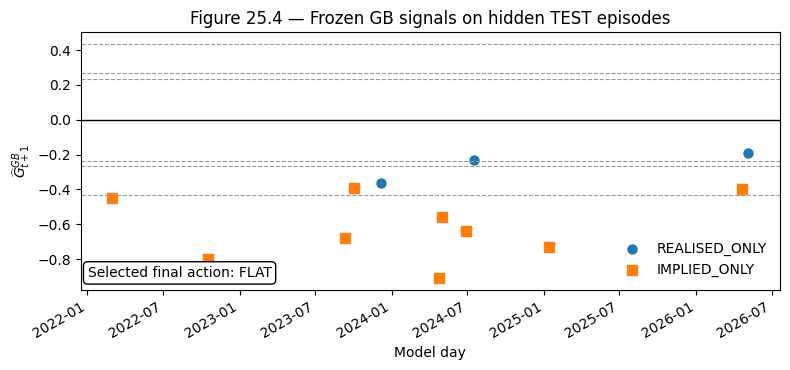

In [14]:
summary_rows = []
for hidden_type in ["REALISED_ONLY", "IMPLIED_ONLY"]:
    frame = economic_episodes.loc[economic_episodes.hidden_type.eq(hidden_type)]
    ml_action = actions(frame, "ML_SIGN")
    type_action = actions(frame, "TYPE_ONLY")
    long_action = actions(frame, "ALWAYS_LONG")
    def mean_return(action):
        pnl = np.where(action > 0, frame.long_pnl_bidask, np.where(action < 0, frame.short_pnl_bidask, 0.))
        return float(np.mean(pnl / frame.spot_entry_mid)) if len(frame) else np.nan
    summary_rows.append({"hidden_type": hidden_type, "candidate_episodes": int(hidden_test.hidden_type.eq(hidden_type).sum()), "economically_evaluable": len(frame), "mean_combined_GB_signal": float(frame.G_hat_COMBINED.mean()) if len(frame) else np.nan, "median_combined_GB_signal": float(frame.G_hat_COMBINED.median()) if len(frame) else np.nan, "ML_SIGN_long": int((ml_action > 0).sum()), "ML_SIGN_short": int((ml_action < 0).sum()), "ML_SIGN_flat": int((ml_action == 0).sum()), "ML_SIGN_mean_return": mean_return(ml_action), "TYPE_ONLY_mean_return": mean_return(type_action), "ALWAYS_LONG_mean_return": mean_return(long_action), "FLAT_mean_return": 0.})
test_hidden_type_summary = pd.DataFrame(summary_rows)
display(test_hidden_type_summary.round(6))

fig, ax = plt.subplots(figsize=(8, 3.8))
for hidden_type, marker in [("REALISED_ONLY", "o"), ("IMPLIED_ONLY", "s")]:
    frame = economic_episodes.loc[economic_episodes.hidden_type.eq(hidden_type)]
    ax.scatter(frame.model_day, frame.G_hat_COMBINED, label=hidden_type, marker=marker, s=42)
ax.axhline(0, color="black", linewidth=1)
for threshold in frozen_thresholds: ax.axhline(threshold, color="#999999", linestyle="--", linewidth=.8); ax.axhline(-threshold, color="#999999", linestyle="--", linewidth=.8)
ax.text(.01, .05, "Selected final action: FLAT", transform=ax.transAxes, bbox={"boxstyle": "round", "facecolor": "white"})
ax.set(xlabel="Model day", ylabel="$\\widehat G_{t+1}^{GB}$", title="Figure 25.4 — Frozen GB signals on hidden TEST episodes")
ax.legend(frameon=False); fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES / "25_figure_hidden_test_gb_signals.png", dpi=180); plt.show()

# 13. Final predictive and economic interpretation

Incremental predictive information and economic exploitability are separate questions. The official economic result is governed by the frozen FLAT policy, regardless of counterfactual benchmark outcomes.

,topic,statement
0,Primary predictive conclusion,The validation incremental predictive improvem...
1,Primary economic conclusion,The pre-TEST validation procedure selected FLA...
2,Selected policy,FLAT total PnL = 0 JPY; J is undefined (0/0).


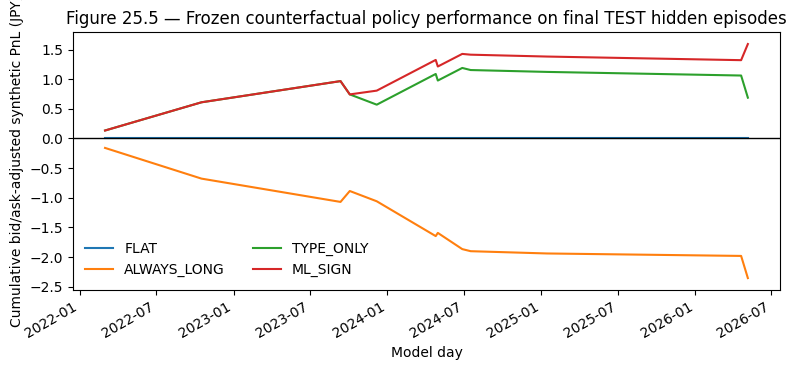

Only FLAT was selected pre-TEST; every non-FLAT line is a frozen counterfactual benchmark.


In [15]:
predictive_text = "The validation incremental predictive improvement persists in untouched TEST data." if observed_test_delta < 0 else "The validation incremental predictive improvement does not persist in untouched TEST data."
if observed_test_delta < 0 and test_bootstrap_summary.p97_5.iloc[0] < 0: predictive_text += " The TEST block-bootstrap interval is also fully below zero."
interpretation = pd.DataFrame([("Primary predictive conclusion", predictive_text), ("Primary economic conclusion", "The pre-TEST validation procedure selected FLAT; no GB-driven strategy was deployed."), ("Selected policy", "FLAT total PnL = 0 JPY; J is undefined (0/0).")], columns=["topic", "statement"])
display(interpretation)

fig, ax = plt.subplots(figsize=(8, 3.8))
for policy in ["FLAT", "ALWAYS_LONG", "TYPE_ONLY", "ML_SIGN"]:
    item = next(row for row in policy_results if row["policy"] == policy)
    ax.plot(economic_episodes.model_day, np.cumsum(item["pnl"]), label=policy)
ax.axhline(0, color="black", linewidth=1)
ax.set(xlabel="Model day", ylabel="Cumulative bid/ask-adjusted synthetic PnL (JPY)", title="Figure 25.5 — Frozen counterfactual policy performance on final TEST hidden episodes")
ax.legend(frameon=False, ncol=2); fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES / "25_figure_frozen_counterfactual_test_pnl.png", dpi=180); plt.show()
print("Only FLAT was selected pre-TEST; every non-FLAT line is a frozen counterfactual benchmark.")

# 14. Limitations

The TEST period is finite and the hidden-event economic sample is small, so economic metrics are descriptive. GB forecasts conditional forward errors and does not identify structural causal effects. N23 contracts are synthetic: raw observed ATM IV and observed spot bid/ask hedge costs are used, but dealer premiums and option bid/ask spreads are unavailable. A profitable TEST benchmark cannot retrospectively alter the frozen FLAT policy.

# 15. Closure and exports

The following computed closure asserts the freeze, target reconstruction, model loading, N23 equivalence, option mechanics, hidden universe, policy integrity, and absence of post-TEST fitting.

In [16]:
import nbformat
saved_notebook = nbformat.read(PROJECT_DIR / "25_application_final_test_evaluation.ipynb", as_version=4)
opening_index = next(index for index, cell in enumerate(saved_notebook.cells) if "OPEN_FINAL_TEST = True" in "".join(cell.source))
closure_index = next(index for index, cell in enumerate(saved_notebook.cells) if "saved_notebook = nbformat.read" in "".join(cell.source))
post_opening_source = "\n".join("".join(cell.source) for cell in saved_notebook.cells[opening_index + 1:closure_index] if cell.cell_type == "code")
no_post_test_fit = ".fit(" not in post_opening_source
no_economic_bootstrap = "economic_bootstrap" not in post_opening_source.lower() and "policy_bootstrap" not in post_opening_source.lower()
fixed_iv = ledger.loc[ledger.application_stage.eq("TEST")].groupby(["model_day", "position_side"]).contract_iv.agg(lambda values: values.max() - values.min()).le(1e-14).all()
no_interpolation = set(test_hedge_ledger.timestamp).issubset(set(quotes.timestamp))
closure_checks = {
    "Pre-TEST freeze manifest verified": freeze_manifest.verification_result.all(),
    "N22/N23/N24 hashes recorded": all(len(value) == 64 for value in upstream_hashes.values()),
    "Frozen GB hashes verified": observed_model_hashes == expected_model_hashes,
    "Frozen policy = FLAT": policy_spec.final_policy.eq("FLAT").all(),
    "TEST opened after freeze verification": OPEN_FINAL_TEST and freeze_manifest_passed,
    "Forward target reproduction verified": target_reconstruction_audit[["max_abs_G_next_error", "max_abs_C_next_error"]].le(TARGET_TOL).all().all(),
    "Exact next_model_day join used": evaluation_panel.R_next.notna().any(),
    "Frozen GB models loaded without refit": no_post_test_fit,
    "Primary TEST comparison completed": len(test_predictive_comparison) == 4,
    "5-day TEST bootstrap completed": BLOCK_LENGTH == 5 and BOOTSTRAP_REPS == 5000 and BOOTSTRAP_SEED == 24,
    "N23 engine equivalence verified": n23_equivalence.passed.all(),
    "TEST contracts use frozen mechanics": no_interpolation and fixed_iv,
    "14 hidden TEST states verified": len(hidden_test) == 14 and hidden_test.hidden_type.eq("REALISED_ONLY").sum() == 4 and hidden_test.hidden_type.eq("IMPLIED_ONLY").sum() == 10,
    "No hidden event silently dropped": hidden_test.model_day.nunique() == 14,
    "Selected policy remained FLAT": test_policy_comparison.loc[test_policy_comparison.selected_pre_test, "policy"].tolist() == ["FLAT"],
    "Non-FLAT policies treated as frozen counterfactuals": test_policy_comparison.loc[~test_policy_comparison.selected_pre_test, "frozen_before_test"].all(),
    "No post-TEST threshold selection": np.allclose(frozen_thresholds, expected_thresholds),
    "No post-TEST model fitting": no_post_test_fit,
    "No economic bootstrap": no_economic_bootstrap,
    "Upstream notebooks unchanged": all(path.is_file() for path in [n22_notebook, n23_notebook, n24_notebook]),
    "Notebook warnings": len(execution_warning_log) == 0,
}
closure = pd.DataFrame({"Check": list(closure_checks), "Result": list(closure_checks.values())})
display(closure)
assert closure.Result.all()

run_metadata = pd.DataFrame([{"notebook": "25_application_final_test_evaluation.ipynb", "execution_timestamp_utc": datetime.now(timezone.utc).isoformat(), "n22_sha256": upstream_hashes["N22"], "n23_sha256": upstream_hashes["N23"], "n24_sha256": upstream_hashes["N24"], "frozen_s_only_model_hash": observed_model_hashes["S_ONLY"], "frozen_hidden_only_model_hash": observed_model_hashes["HIDDEN_ONLY"], "frozen_combined_model_hash": observed_model_hashes["COMBINED"], "model_artifact_paths": json.dumps({family: model_spec.loc[model_spec.feature_family.eq(family), "model_artifact_path"].iloc[0] for family in feature_sets}), "frozen_final_policy": policy_spec.final_policy.iloc[0], "frozen_thresholds": json.dumps(frozen_thresholds), "frozen_target": "C_next", "frozen_features": json.dumps(feature_sets), "frozen_gb_hyperparameters": "n_estimators=100; learning_rate=0.05; loss=squared_error; max_depth=1; min_samples_leaf=20; random_state=24", "frozen_risk_weighted_objective": policy_spec.risk_weighted_objective.iloc[0], "formal_test_opening": OPEN_FINAL_TEST, "test_statistical_sample_size": len(test_forecasts), "test_hidden_event_count": len(hidden_test), "test_economically_evaluable_hidden_count": len(economic_episodes), "n23_equivalence_passed": n23_equivalence_passed, "no_post_test_fit": no_post_test_fit, "python_version": platform.python_version()}])
exports = {"25_pretest_freeze_manifest.csv": freeze_manifest, "25_test_predictive_comparison.csv": test_predictive_comparison, "25_test_predictive_bootstrap.csv": pd.DataFrame({"delta_rmse": test_bootstrap_deltas}), "25_test_option_pnl_panel.csv": test_option_panel, "25_test_hedge_ledger.csv": test_hedge_ledger, "25_test_contract_coverage.csv": test_contract_coverage, "25_test_hidden_event_economic_panel.csv": hidden_test, "25_test_policy_comparison.csv": test_policy_comparison, "25_test_hidden_type_summary.csv": test_hidden_type_summary, "25_run_metadata.csv": run_metadata}
temporary = {}
for name, frame in exports.items():
    temporary[name] = PROCESSED / f".{name}.tmp"; frame.to_csv(temporary[name], index=False)
for name, temp in temporary.items(): temp.replace(PROCESSED / name)
print("N25 closure: PASS")

,Check,Result
0,Pre-TEST freeze manifest verified,True
1,N22/N23/N24 hashes recorded,True
2,Frozen GB hashes verified,True
3,Frozen policy = FLAT,True
4,TEST opened after freeze verification,True
5,Forward target reproduction verified,True
6,Exact next_model_day join used,True
7,Frozen GB models loaded without refit,True
8,Primary TEST comparison completed,True
9,5-day TEST bootstrap completed,True


N25 closure: PASS
